### Import Modules

In [1]:
# Standard Library
import random
from datetime import datetime, timezone
from os import environ

# Packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from dotenv import load_dotenv
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
)
from sqlalchemy import create_engine, text

### Constants & Config

In [2]:
# Environment
load_dotenv()

# SQL
ENGINE = create_engine(
    f"postgresql://{environ['POSTGRES_USER']}:{environ['POSTGRES_PASSWORD']}"
    f"@{environ['POSTGRES_HOST']}:{environ['POSTGRES_PORT']}/{environ['FRAUD_DETECTION_DB']}"
)

# Reproducibility
RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

### Read data from SQL

In [3]:
start_time = datetime(2019, 1, 1, tzinfo=timezone.utc)
end_time = datetime(2019, 1, 3, tzinfo=timezone.utc)

query = f"""
    SELECT DISTINCT ON (transaction_id)
        EXTRACT(EPOCH FROM transaction_timestamp)::INTEGER AS transaction_timestamp,
        amount,
        {",".join([f"v{i}" for i in range(1, 29)])},
        is_fraud::INTEGER
    FROM transaction_inferences
    WHERE transaction_timestamp BETWEEN :start_time AND :end_time
"""
df = pd.read_sql(
    text(query), ENGINE,
    params={
        "start_time": datetime(2019, 1, 1, tzinfo=timezone.utc),
        "end_time": datetime.now(tz=timezone.utc),
    }
)

print(f"Loaded {len(df):,} rows")
df.head()

Loaded 284,807 rows


,transaction_timestamp,amount,v1,v2,v3,v4,v5,v6,v7,v8,...,v20,v21,v22,v23,v24,v25,v26,v27,v28,is_fraud
0,1546333158,45.00,1.079365,0.048546,1.338433,1.357557,-1.050052,-0.589543,-0.409676,-0.037649,...,-0.003219,0.156442,0.434422,-0.007908,0.733404,0.305933,-0.388239,0.060015,0.052250,0
1,1546446699,117.00,1.782987,-0.834805,-0.574236,0.201291,-0.722902,-0.216241,-0.579421,0.060928,...,0.031025,0.264445,0.599855,0.041227,-0.361393,-0.386450,0.646388,-0.063887,-0.044458,0
2,1546352943,8.99,-0.825850,0.813128,2.426074,-0.035323,-0.474062,-0.317309,0.231861,0.277409,...,0.031806,-0.045753,-0.119447,-0.099858,0.361219,-0.029777,0.278525,0.281630,0.133343,0
3,1546353258,10.00,1.256677,0.208935,0.171589,1.147307,-0.238629,-0.633712,0.022575,-0.081581,...,-0.214588,0.023077,0.030996,-0.157399,-0.153528,0.684891,-0.244892,0.006347,0.014574,0
4,1546427755,1.00,2.045226,0.455282,-2.363337,1.477942,0.914136,-0.971208,0.571373,-0.253545,...,-0.323599,-0.061378,-0.018174,0.025248,0.513164,0.444503,-0.514202,-0.008667,-0.026661,0


### Exploratory Data Analysis

Shape: (284807, 31)
Null Total: 0


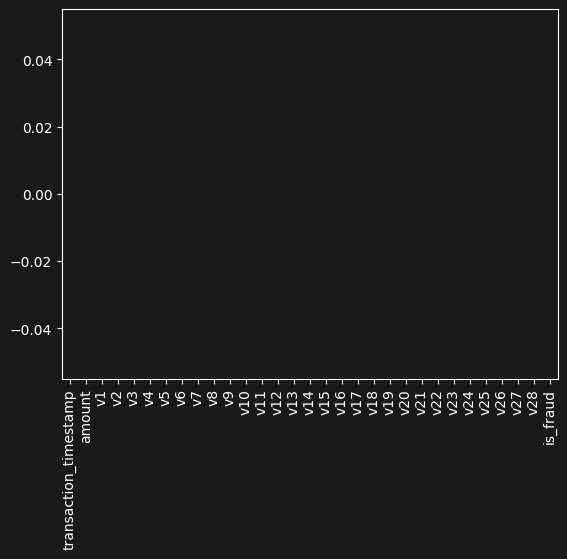

In [4]:
# Basic overview
print(f"Shape: {df.shape}")
print(f"Null Total: {df.isnull().sum().sum()}")
df.isnull().sum().plot(kind='bar')
plt.show()

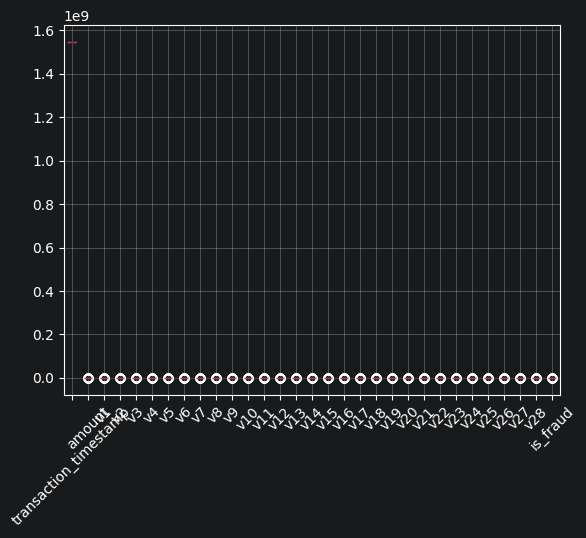

In [5]:
# Feature Distribution
df.boxplot()
plt.xticks(rotation=45)
plt.show()

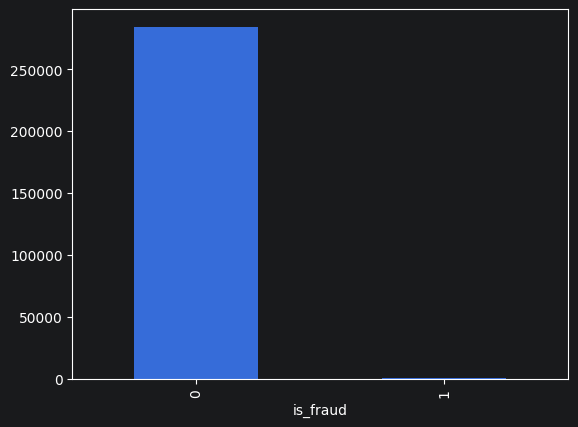

In [6]:
# Class distribution
df["is_fraud"].value_counts().plot(kind="bar")
plt.show()

In [7]:
# fig = px.scatter_matrix(df,
#     dimensions=['transaction_timestamp', 'amount', 'v1'],
#     color="is_fraud",
#     category_orders={"is_fraud": [0, 1]}
# )
# fig.update_traces(diagonal_visible=False, showupperhalf=False)
# fig.show(renderer="svg")

### Handling Missing Values

Null Total: 427020


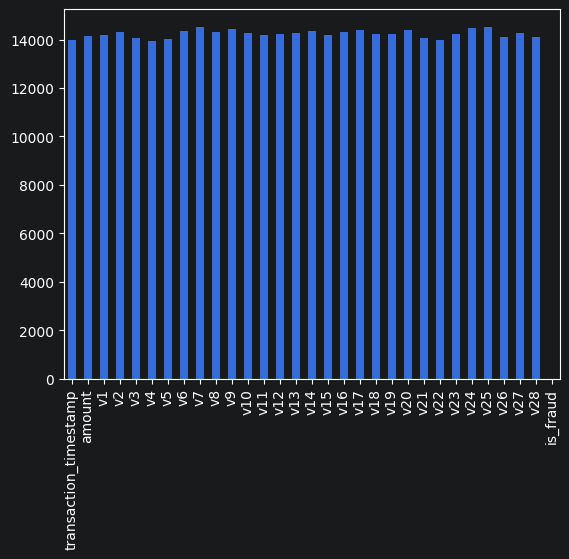

In [8]:
# Simulate missing values for learning (creditcard_transactions.csv has none)
df_for_hmv_tmp = df.copy()
columns_to_mask = df_for_hmv_tmp.columns.drop(["is_fraud"])
mask = RNG.random(df_for_hmv_tmp[columns_to_mask].shape) < 0.05
df_for_hmv_tmp[columns_to_mask] = df_for_hmv_tmp[columns_to_mask].mask(mask)

print(f"Null Total: {df_for_hmv_tmp.isnull().sum().sum()}")
df_for_hmv_tmp.isnull().sum().plot(kind='bar')
plt.show()

In [9]:
# Drop rows (only when very few missing)
df_for_hmv_dropped_tmp = df_for_hmv_tmp.dropna()

print(f"Dropped: {len(df_for_hmv_tmp) - len(df_for_hmv_dropped_tmp):,} rows with null")
print(f"Rows: {len(df_for_hmv_tmp):,} to {len(df_for_hmv_dropped_tmp):,}")
print(f"Null Total: {df_for_hmv_dropped_tmp.isnull().sum().sum():,}")

Dropped: 223,752 rows with null
Rows: 284,807 to 61,055
Null Total: 0


In [10]:
# Mean/Median imputation (numerical)
columns_to_skip = ["is_fraud"]
imputer_median = SimpleImputer(strategy="median").set_output(transform="pandas")
df_for_hmv_imputed_median_tmp = imputer_median.fit_transform(
    df_for_hmv_tmp.drop(columns=columns_to_skip)
)

df_for_hmv_imputed_median_tmp[columns_to_skip] = df_for_hmv_tmp[columns_to_skip].values

print(f"Rows: {len(df_for_hmv_tmp):,} to {len(df_for_hmv_imputed_median_tmp):,}")
print(f"Null Total: {df_for_hmv_imputed_median_tmp.isnull().sum().sum():,}")

Rows: 284,807 to 284,807
Null Total: 0


In [11]:
# # KNN Imputation (captures feature relationships but expensive on large data)
# imputer_knn = KNNImputer(n_neighbors=5).set_output(transform="pandas")
#
# df_for_hmv_imputed_knn_tmp = imputer_knn.fit_transform(tmp_df_for_hmv)
#
# print(f"Rows: {len(tmp_df_for_hmv):,} to {len(df_for_hmv_imputed_knn_tmp):,}")
# print(f"Null Total: {df_for_hmv_imputed_knn_tmp.isnull().sum().sum()}")
#
# # Interview answer: "I choose strategy based on (1) % missing, (2) MCAR vs MAR vs MNAR,
# # (3) model type. Tree models handle NaNs natively; linear models need imputation."

### Scaling Features

In [12]:
# Do it for distance/gradient based models (KNN/SVM/Linear/Logistic/NN)
# Don't do it for tree-based models (DT/RF/XGBoost)
# If it's done even to a single feature. It's important to do it to all other features.
df_for_sf_tmp = df.copy()

# Standardization (Z-score): mean=0, std=1 → assumes roughly Gaussian
std_scaler_for_sf_tmp = StandardScaler().set_output(transform="pandas")
# Normalization (Min-Max): scales to [0, 1]
minmax_scaler_for_sf_tmp = MinMaxScaler().set_output(transform="pandas")
# Robust: uses median & IQR → robust to outliers
robust_scaler_for_sf_tmp = RobustScaler().set_output(transform="pandas")

df_for_sf_tmp["amount_std"] = std_scaler_for_sf_tmp.fit_transform(df_for_sf_tmp[["amount"]])
df_for_sf_tmp["amount_minmax"] = minmax_scaler_for_sf_tmp.fit_transform(df_for_sf_tmp[["amount"]])
df_for_sf_tmp["amount_robust"] = robust_scaler_for_sf_tmp.fit_transform(df_for_sf_tmp[["amount"]])
df_for_sf_tmp["amount_log"] = np.log1p(df_for_sf_tmp["amount"])

# CRITICAL: fit on train, transform on train AND test
# NEVER fit on the full dataset — that's data leakage!

In [13]:
# Uses CV so scaling should be done per CV iteration
# x = df.drop("Class", axis=1)
# y = df["Class"]
#
# train_x, test_x, train_y, test_y = train_test_split(
#     x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
# )
#
# # RobustScaler: uses median & IQR → robust to outliers
# robust_scaler = RobustScaler().set_output(transform="pandas")
#
# train_x_scaled = robust_scaler.fit_transform(train_x)
# test_x_scaled = robust_scaler.transform(test_x)
#
# print(f"Loaded {len(train_x_scaled) + len(test_x_scaled):,} rows")
# pd.concat([
#     pd.concat([train_x_scaled, train_y], axis=1),
#     pd.concat([test_x_scaled, test_y], axis=1)
# ]).head()

### Categorical Encoding

In [14]:
# creditcard_transactions.csv is all numerical; simulate a categorical column for learning
df_for_ce_tmp = df.copy()
df_for_ce_tmp["merchant_type"] = RNG.choice(
    ["Online", "Retail", "ATM", "Restaurant"],
    len(df_for_ce_tmp)
)
df_for_ce_tmp["size"] = RNG.choice(["Small", "Medium", "Large"], len(df_for_ce_tmp))

df_for_ce_category_columns_tmp = df_for_ce_tmp.select_dtypes(exclude="number").columns
df_for_ce_tmp[df_for_ce_category_columns_tmp].head()

,merchant_type,size
0,Restaurant,Small
1,ATM,Small
2,Restaurant,Medium
3,Online,Medium
4,ATM,Large


In [15]:
df_for_ce_encoded_tmp = df_for_ce_tmp.copy()

# Label Encoding — no order, mostly used for target feature
label_encoder = LabelEncoder()
# Ordinal Encoding — ordinal categories only (categories=order by index)
ordinal_encoder = OrdinalEncoder(
    categories=[["Small", "Medium", "Large"]]
).set_output(transform="pandas")
# One-Hot Encoding — nominal categories, low cardinality (<20 unique values)
one_hot_encoder = OneHotEncoder(drop="first", sparse_output=False).set_output(transform="pandas")

df_for_ce_encoded_tmp["is_fraud"] = label_encoder.fit_transform(df_for_ce_tmp["is_fraud"])
df_for_ce_encoded_tmp["size"] = ordinal_encoder.fit_transform(df_for_ce_tmp[["size"]])
# tmp_df_for_ce = one_hot_encoder.fit_transform(tmp_df_for_ce[["Merchant_Type"]])
# pd.get_dummies(tmp_df_for_ce, columns=["Merchant_Type"], drop_first=True, dtype=int)
df_for_ce_encoded_tmp = pd.concat(
    [
        df_for_ce_encoded_tmp.drop(columns="merchant_type"),
        pd.DataFrame(one_hot_encoder.fit_transform(df_for_ce_tmp[["merchant_type"]]))
    ],
    axis=1
)

df_for_ce_encoded_columns_tmp = df_for_ce_encoded_tmp.columns
df_for_ce_encoded_tmp[
    df_for_ce_encoded_columns_tmp[
        df_for_ce_encoded_columns_tmp.isin(df_for_ce_category_columns_tmp) |
        ~df_for_ce_encoded_columns_tmp.isin(df_for_ce_tmp.columns)
        ]
].head()

,size,merchant_type_Online,merchant_type_Restaurant,merchant_type_Retail
0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0
2,1.0,0.0,1.0,0.0
3,1.0,1.0,0.0,0.0
4,2.0,0.0,0.0,0.0


### Handling Outliers

In [16]:
# Always check first if its data related error
# - Outlier is always a real data unless it isn't
# Always check the task/problem
# - The outlier is the signal at some task (Fraud/Anomaly/Volatile Detection)
# Always check if you don't need to handle the outliers
# - Only remove it if the outlier data are not as important as the general
# This is mostly used for variance sensitive models (Linear/PCA/NN)
df_ho_tmp = df.copy()

df_ho_Q1_tmp = df_ho_tmp["amount"].quantile(0.25)
df_ho_Q3_tmp = df_ho_tmp["amount"].quantile(0.75)
df_ho_IQR_tmp = df_ho_Q3_tmp - df_ho_Q1_tmp
df_ho_lower_tmp = df_ho_Q1_tmp - 1.5 * df_ho_IQR_tmp
df_ho_upper_tmp = df_ho_Q3_tmp + 1.5 * df_ho_IQR_tmp
df_ho_outliers_tmp = df_ho_tmp[
    (df["amount"] < df_ho_lower_tmp) | (df_ho_tmp["amount"] > df_ho_upper_tmp)
]

print(f"Non-outlier Range: {df_ho_lower_tmp:.2f} to {df_ho_upper_tmp:.2f}")
print(f"Outliers: {len(df_ho_outliers_tmp):,} ({100 * len(df_ho_outliers_tmp) / len(df):.2f}%)")
df_ho_outliers_tmp.head()

Non-outlier Range: -101.75 to 184.51
Outliers: 31,904 (11.20%)


,transaction_timestamp,amount,v1,v2,v3,v4,v5,v6,v7,v8,...,v20,v21,v22,v23,v24,v25,v26,v27,v28,is_fraud
21,1546431484,240.79,1.454939,-0.107976,-0.495232,3.888606,-0.064528,-0.273448,0.447638,-0.162728,...,0.198877,-0.295691,-1.514116,0.359479,-0.078957,-0.740002,-0.662031,-0.068275,0.011692,0
27,1546337259,960.74,-0.659370,-3.044603,-0.238100,1.344855,-1.595395,0.037226,0.939430,-0.227786,...,1.911314,0.590183,-0.318398,-0.885016,0.450833,0.031681,0.356150,-0.194967,0.174648,0
40,1546419060,499.95,1.433146,-2.832040,-1.996516,-1.225236,-1.340951,-0.604542,-0.202561,-0.460314,...,0.557586,0.226834,0.124802,-0.427280,-0.674936,-0.006952,0.026988,-0.095843,0.017232,0
71,1546421675,201.00,-4.306705,-5.622643,1.632428,-1.040371,4.177861,-1.208398,-3.056812,0.971743,...,1.704744,0.989813,1.072118,0.872480,-1.642139,0.718731,0.163590,-0.155600,0.136807,0
77,1546433279,1673.00,-3.777994,-6.087816,-4.101831,-1.088452,-1.216038,-0.367725,6.380516,-1.008405,...,3.921540,1.563494,1.355126,4.115840,-0.586462,-0.337459,0.475056,-0.381939,0.283483,0


In [17]:
# IQR Removal (only if few & clearly erroneous <5%)
df_for_ho_iqr_removal_tmp = df_ho_tmp[df_ho_tmp["amount"].between(df_ho_lower_tmp, df_ho_upper_tmp)]
df_for_ho_iqr_removal_range_tmp = len(df_ho_tmp) - len(df_for_ho_iqr_removal_tmp)
print(
    f"Dropping outliers will remove: {df_for_ho_iqr_removal_range_tmp:,} or {df_for_ho_iqr_removal_range_tmp / len(df_ho_tmp) * 100:.2f}% rows "
    f"({len(df_ho_tmp):,} to {len(df_for_ho_iqr_removal_tmp):,})"
)

# Winsorization — cap at 5th/95th percentile (keeps the row)
df_for_ho_win_p5_tmp, df_for_ho_win_p95_tmp = df_ho_tmp["amount"].quantile([0.05, 0.95])
df_ho_tmp["amount_capped"] = df_ho_tmp["amount"].clip(
    lower=df_for_ho_win_p5_tmp,
    upper=df_for_ho_win_p95_tmp
)

# Transform (log, sqrt) — makes distribution more symmetric
df_ho_tmp["amount_log"] = np.log1p(df_ho_tmp["amount"])

# - Use robust models (tree-based methods are outlier-resistant)
# - Use RobustScaler (as above)

# Interview: "In fraud data, extreme amounts might BE the fraud signal — don't blindly remove.
# I inspect domain context first."
df_ho_tmp.head()

Dropping outliers will remove: 31,904 or 11.20% rows (284,807 to 252,903)


,transaction_timestamp,amount,v1,v2,v3,v4,v5,v6,v7,v8,...,v22,v23,v24,v25,v26,v27,v28,is_fraud,amount_capped,amount_log
0,1546333158,45.00,1.079365,0.048546,1.338433,1.357557,-1.050052,-0.589543,-0.409676,-0.037649,...,0.434422,-0.007908,0.733404,0.305933,-0.388239,0.060015,0.052250,0,45.00,3.828641
1,1546446699,117.00,1.782987,-0.834805,-0.574236,0.201291,-0.722902,-0.216241,-0.579421,0.060928,...,0.599855,0.041227,-0.361393,-0.386450,0.646388,-0.063887,-0.044458,0,117.00,4.770685
2,1546352943,8.99,-0.825850,0.813128,2.426074,-0.035323,-0.474062,-0.317309,0.231861,0.277409,...,-0.119447,-0.099858,0.361219,-0.029777,0.278525,0.281630,0.133343,0,8.99,2.301585
3,1546353258,10.00,1.256677,0.208935,0.171589,1.147307,-0.238629,-0.633712,0.022575,-0.081581,...,0.030996,-0.157399,-0.153528,0.684891,-0.244892,0.006347,0.014574,0,10.00,2.397895
4,1546427755,1.00,2.045226,0.455282,-2.363337,1.477942,0.914136,-0.971208,0.571373,-0.253545,...,-0.018174,0.025248,0.513164,0.444503,-0.514202,-0.008667,-0.026661,0,1.00,0.693147


### Handling Imbalanced Classes

In [18]:
# Do it if cost of minority class is high (Medical/Security/Fraud)
# Often, you don't need to resample the data when using Precision-Recall AUC or F1-Score is enough.
# - Resampling can sometimes lead the model to overfit on "fake" synthetic data.

df_for_hic_tmp = df.copy()

# Never just over/under-sample without being inside a CV fold — that's leakage.
x_for_hic_tmp = df_for_hic_tmp.drop("is_fraud", axis=1)
y_for_hic_tmp = df_for_hic_tmp["is_fraud"]

train_x_for_hic_tmp, test_x_for_hic_tmp, train_y_for_hic_tmp, test_y_for_hic_tmp = train_test_split(
    x_for_hic_tmp, y_for_hic_tmp,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_for_hic_tmp
)

print(f"Training samples: {len(train_x_for_hic_tmp):,}")
print(f"Training classes:")
train_y_for_hic_tmp.value_counts()

Training samples: 227,845
Training classes:


is_fraud
0    227451
1       394
Name: count, dtype: int64

In [19]:
# Omitting samples of existing majority samples randomly
rus_for_hic_tmp = RandomUnderSampler(random_state=RANDOM_STATE)
# Duplicating samples of existing minority samples randomly
ros_for_hic_tmp = RandomOverSampler(random_state=RANDOM_STATE)
# Generates synthetic samples by interpolating between existing minority samples
smote_for_hic_tmp = SMOTE(random_state=RANDOM_STATE) # Synthetic Minority Oversampling Technique

train_x_for_hic_rus_tmp, train_y_for_hic_rus_tmp = rus_for_hic_tmp.fit_resample(
    train_x_for_hic_tmp,
    train_y_for_hic_tmp
)
train_x_for_hic_ros_tmp, train_y_for_hic_ros_tmp = ros_for_hic_tmp.fit_resample(
    train_x_for_hic_tmp,
    train_y_for_hic_tmp
)
train_x_smote_tmp, train_y_smote_tmp = smote_for_hic_tmp.fit_resample(
    train_x_for_hic_tmp,
    train_y_for_hic_tmp
)

print("Training classes after resampling:\n")
print(f"Undersampling\n{train_y_for_hic_rus_tmp.value_counts()}\n")
print(f"Oversampling\n{train_y_for_hic_ros_tmp.value_counts()}\n")
print(f"SMOTE\n{train_y_smote_tmp.value_counts()}")

# # Method 2: Class weights — penalize misclassifying minority class more
# # Most sklearn models have class_weight='balanced'
# from sklearn.linear_model import LogisticRegression
# model_weighted = LogisticRegression(class_weight='balanced', max_iter=1000)

# # Method 3: Ensemble methods (XGBoost scale_pos_weight)
# import xgboost as xgb
# neg, pos = (y_train_imbalance == 0).sum(), (y_train_imbalance == 1).sum()
# model_xgb = xgb.XGBClassifier(scale_pos_weight=neg/pos, random_state=RANDOM_STATE)

# Interview: "I never just oversample without being inside a CV fold — that's leakage.
# SMOTE goes inside the pipeline, not before train/test split."

Training classes after resampling:

Undersampling
is_fraud
0    394
1    394
Name: count, dtype: int64

Oversampling
is_fraud
0    227451
1    227451
Name: count, dtype: int64

SMOTE
is_fraud
0    227451
1    227451
Name: count, dtype: int64


In [20]:
x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

train_x, test_x, train_y, test_y = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

smote = SMOTE(random_state=RANDOM_STATE)
train_x_smote, train_y_smote = smote.fit_resample(train_x, train_y)

# Collect split data
data_sets = {
    'train_x': train_x_smote, 'train_y': train_y_smote,
    'test_x': test_x, 'test_y': test_y
}

# Save to sql (ACID transaction)
with ENGINE.begin() as connection:
    for suffix, data in data_sets.items():
        data.to_sql(
            f"preprocessed_transactions_{suffix}",
            con=connection,
            if_exists='replace',
            index=False
        )

print(f"Train classes before SMOTE\n{pd.Series(train_y).value_counts()}\n")
print(f"Train classes after SMOTE\n{train_y_smote.value_counts()}\n")
pd.concat([
    pd.concat([train_x_smote, train_y_smote], axis=1),
    pd.concat([test_x, test_y], axis=1)
]).head()

Train classes before SMOTE
is_fraud
0    227451
1       394
Name: count, dtype: int64

Train classes after SMOTE
is_fraud
0    227451
1    227451
Name: count, dtype: int64



,transaction_timestamp,amount,v1,v2,v3,v4,v5,v6,v7,v8,...,v20,v21,v22,v23,v24,v25,v26,v27,v28,is_fraud
0,1546345919,321.95,-1.348690,0.900014,1.984170,-0.008635,-1.661308,1.145644,1.704313,0.030943,...,-0.513417,0.042434,0.197953,-0.214079,0.193509,0.139526,-0.566548,-0.095270,-0.060117,0
1,1546442725,1.29,-0.798195,0.887285,1.339229,-1.053335,0.696300,-1.091852,1.204520,-0.183783,...,-0.135801,-0.285071,-0.901945,-0.307787,0.035606,0.562455,0.235007,-0.067150,0.037503,0
2,1546343889,93.23,1.030646,-0.573638,1.217802,0.308482,-1.452995,-0.621280,-0.553976,-0.015796,...,0.113430,-0.042442,-0.109730,0.022977,0.798816,0.045704,0.960357,-0.047937,0.034912,0
3,1546436848,29.56,2.030186,0.234072,-2.514668,0.769865,0.730890,-0.943608,0.242111,-0.264767,...,-0.090425,-0.049601,0.156223,-0.150498,-0.912593,0.283439,0.774545,-0.038409,-0.016644,0
4,1546451631,3.08,-0.478713,1.177304,-0.941223,-0.902117,1.314958,0.130906,0.692979,-0.070038,...,0.076935,0.042747,0.394439,-0.043010,-0.247729,-0.826477,0.221383,-0.659592,-0.261492,0


### Feature Selection

In [21]:
# Do it when one have the "Curse of Dimensionality" (Many Features but has Few Data)
# Don't do it when using models with L1 (Lasso/Elastic-Net)
# - Since they already create sparsity, they already drop features in their own during training.
df_for_fs_tmp = df.copy()

x_for_fs_tmp = df_for_fs_tmp.drop("is_fraud", axis=1)
y_for_fs_tmp = df_for_fs_tmp["is_fraud"]

train_x_for_fs_tmp, test_x_for_fs_tmp, train_y_for_fs_tmp, test_y_for_fs_tmp = train_test_split(
    x_for_fs_tmp, y_for_fs_tmp,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y_for_fs_tmp
)

print(f"Training samples: {len(train_x_for_fs_tmp):,}")
print(f"Testing samples: {len(test_x_for_fs_tmp):,}")

Training samples: 227,845
Testing samples: 56,962


In [22]:
# creditcard_transactions.csv already uses PCA values so its already ordered
train_x_scaled_for_fs_tmp = RobustScaler().set_output(
    transform="pandas"
).fit_transform(train_x_for_fs_tmp)

# Univariate statistical tests (fast, ignores interactions)
k_best_selector_for_fs_tmp = SelectKBest(f_classif, k=15)
k_best_selector_for_fs_tmp.fit(train_x_scaled_for_fs_tmp, train_y_for_fs_tmp)
k_best_selected_features_for_fs_tmp = train_x_scaled_for_fs_tmp.columns[
    k_best_selector_for_fs_tmp.get_support()
]
print("F-test selected:", k_best_selected_features_for_fs_tmp.tolist())

# # Embedded - Feature importance from tree models (most practical)
# rf_for_fs_tmp = RandomForestClassifier(
#     n_estimators=100,
#     random_state=RANDOM_STATE
# ).fit(train_x_scaled_for_fs_tmp, train_y_for_fs_tmp)
# rf_importances_for_fs_tmp = pd.Series(rf_for_fs_tmp.feature_importances_).sort_values(ascending=False)
# print("RF Feature Importance selected:", rf_importances_for_fs_tmp)

# # RFE — Recursive Feature Elimination (expensive)
# rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
# rfe = RFE(estimator=rf, step=1)
# rfe.fit(X_train_feature_selection, y_train_feature_selection)
# print("RF RFE selected:", X_train_feature_selection.columns[rfe.support_].tolist())

F-test selected: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v9', 'v10', 'v11', 'v12', 'v14', 'v16', 'v17', 'v18']


### Data Leakage

In [23]:
# Data leakage = information from OUTSIDE the training data leaking in
# Types:
#
# 1. Target leakage — feature created using the target
#    BAD:  df['is_fraud_merchant'] = df.groupby('merchant')['Class'].transform('mean')
#          (this uses future knowledge of fraud labels)
#
# 2. Train-test contamination — fitting preprocessors on full dataset
#    BAD:  scaler.fit(X)          → scaler.transform(X_train), scaler.transform(X_test)
#    GOOD: scaler.fit(X_train)    → scaler.transform(X_train), scaler.transform(X_test)
#
# 3. Time leakage — using future data to predict the past
#    BAD:  random shuffle of time-series data
#    GOOD: TimeSeriesSplit for CV on time-ordered data

# # The FIX: sklearn Pipeline (preprocessors fit only on train fold inside CV)
# pipeline = Pipeline([
#     ('scaler', StandardScaler()),         # fit happens only on train fold
#     ('classifier', LogisticRegression())
# ])
#
# tmp_df_for_dl = df.copy()
#
# tmp_X_for_dl = tmp_df_for_dl.drop('Class', axis=1)
# tmp_y_for_dl = tmp_df_for_dl['Class']
#
# tmp_X_train_for_dl, tmp_X_test_for_dl, tmp_y_train_for_dl, tmp_y_test_for_dl = train_test_split(
#     tmp_X_for_dl, tmp_y_for_dl,
#     test_size=0.2, random_state=RANDOM_STATE, stratify=tmp_y_for_dl
# )
#
# pipeline.fit(tmp_X_train_for_dl, tmp_y_train_for_dl) # safe: scaler fits on X_train, transforms X_train
# pipeline.transform(tmp_X_test_for_dl)                # safe: uses train statistics only